In [1]:
import pandas as pd 


In [2]:
pip install mysql-connector-python


Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",        
    password="root",  
    database="heathurt"
)
users = pd.read_sql("SELECT * FROM users", conn)
heat_usage = pd.read_sql("SELECT * FROM heat_usage", conn)
hair_condition = pd.read_sql("SELECT * FROM hair_condition", conn)
print(users)
print(heat_usage)
print(hair_condition)

       user_id  age hair_type
0          501   62      wavy
1          502   35     coily
2          503   53     coily
3          504   50     curly
4          505   47      wavy
...        ...  ...       ...
10495    10496   61  straight
10496    10497   29     curly
10497    10498   49      wavy
10498    10499   19     coily
10499    10500   55  straight

[10500 rows x 3 columns]
       usage_id  user_id     tool_type  temperature_range  duration_min  \
0             1        1        curler             129.92            82   
1             2        2         dryer             162.98            61   
2             3        3         dryer             133.38            24   
3             4        4        curler             100.75            62   
4             5        5  straightener             137.02            18   
...         ...      ...           ...                ...           ...   
10495     10496    10496  straightener             173.24            74   
10496     1049

C:\Users\9f06e\AppData\Local\Temp\ipykernel_54368\1970037349.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  users = pd.read_sql("SELECT * FROM users", conn)
C:\Users\9f06e\AppData\Local\Temp\ipykernel_54368\1970037349.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  heat_usage = pd.read_sql("SELECT * FROM heat_usage", conn)
C:\Users\9f06e\AppData\Local\Temp\ipykernel_54368\1970037349.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  hair_condition = pd.read_sql("SELECT * FROM hair_condition", conn)


In [4]:
merged_df = users.merge(heat_usage, on='user_id').merge(hair_condition, on='user_id')
print(merged_df)
print(merged_df.shape)

       user_id  age hair_type  usage_id     tool_type  temperature_range  \
0          501   62      wavy       501  straightener             243.68   
1          502   35     coily       502  straightener             162.49   
2          503   53     coily       503         dryer             121.19   
3          504   50     curly       504         dryer             188.76   
4          505   47      wavy       505        curler             249.49   
...        ...  ...       ...       ...           ...                ...   
10495    10496   61  straight     10496  straightener             173.24   
10496    10497   29     curly     10497  straightener             168.60   
10497    10498   49      wavy     10498         dryer             131.67   
10498    10499   19     coily     10499  straightener             125.25   
10499    10500   55  straight     10500        curler             123.09   

       duration_min usage_freq  total_usage_months  condition_id  \
0                75

In [5]:
print(merged_df.shape)
print(merged_df.columns.tolist())

(10500, 13)
['user_id', 'age', 'hair_type', 'usage_id', 'tool_type', 'temperature_range', 'duration_min', 'usage_freq', 'total_usage_months', 'condition_id', 'self_reported_condition', 'damage_score', 'report_date']


In [6]:
print(merged_df.dtypes)

user_id                      int64
age                          int64
hair_type                   object
usage_id                     int64
tool_type                   object
temperature_range          float64
duration_min                 int64
usage_freq                  object
total_usage_months           int64
condition_id                 int64
self_reported_condition     object
damage_score                 int64
report_date                 object
dtype: object


In [7]:
print(merged_df.select_dtypes(include='object').columns.tolist())

['hair_type', 'tool_type', 'usage_freq', 'self_reported_condition', 'report_date']


In [8]:
merged_df['hair_type'] = merged_df['hair_type'].map({'straight': 1, 'wavy': 2, 'curly': 3, 'coily': 4})
merged_df['tool_type'] = merged_df['tool_type'].map({'dryer': 1, 'curler': 2, 'straightener': 3})
merged_df['usage_freq'] = merged_df['usage_freq'].map({'monthly': 1, 'weekly': 2, 'daily': 3})
merged_df = merged_df.drop(columns=['self_reported_condition', 'report_date'])
print(merged_df.dtypes)
print(merged_df.head())

user_id                 int64
age                     int64
hair_type               int64
usage_id                int64
tool_type               int64
temperature_range     float64
duration_min            int64
usage_freq              int64
total_usage_months      int64
condition_id            int64
damage_score            int64
dtype: object
   user_id  age  hair_type  usage_id  tool_type  temperature_range  \
0      501   62          2       501          3             243.68   
1      502   35          4       502          3             162.49   
2      503   53          4       503          1             121.19   
3      504   50          3       504          1             188.76   
4      505   47          2       505          2             249.49   

   duration_min  usage_freq  total_usage_months  condition_id  damage_score  
0            75           3                  36           501             5  
1            45           2                   6           502             3  
2

In [9]:
print(merged_df.isnull().sum())

user_id               0
age                   0
hair_type             0
usage_id              0
tool_type             0
temperature_range     0
duration_min          0
usage_freq            0
total_usage_months    0
condition_id          0
damage_score          0
dtype: int64


In [10]:
import matplotlib.pyplot as plt

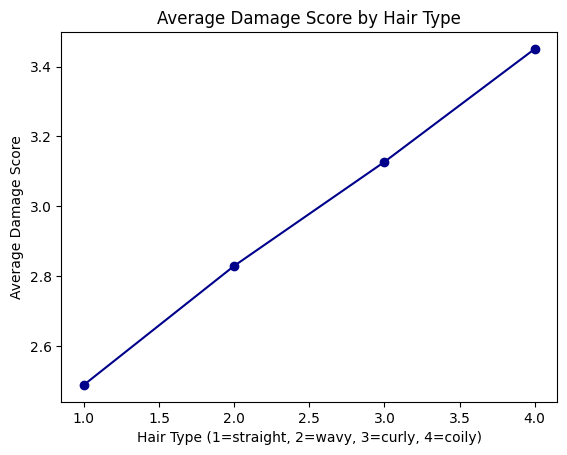

In [11]:
merged_df.groupby('hair_type')['damage_score'].mean().plot(kind='line', color='darkblue', marker='o')
plt.title('Average Damage Score by Hair Type')
plt.xlabel('Hair Type (1=straight, 2=wavy, 3=curly, 4=coily)')
plt.ylabel('Average Damage Score')
plt.show()

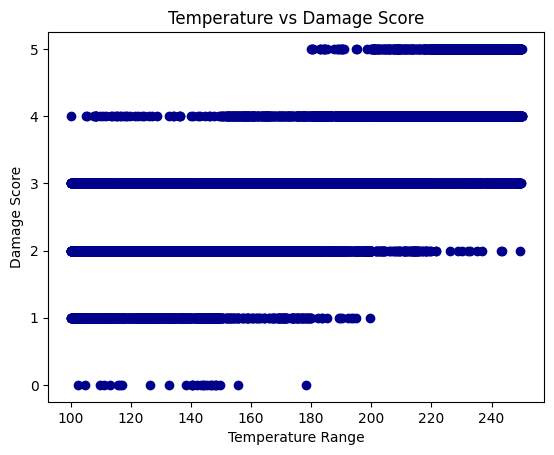

In [12]:
plt.scatter(merged_df['temperature_range'], merged_df['damage_score'], color='darkblue')
plt.title('Temperature vs Damage Score')
plt.xlabel('Temperature Range')
plt.ylabel('Damage Score')
plt.show()

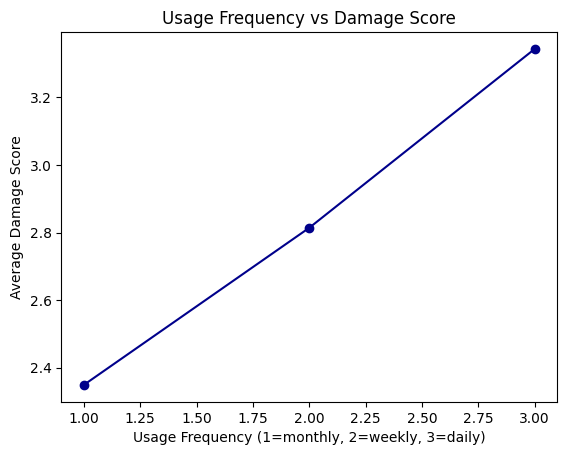

In [22]:
merged_df.groupby('usage_freq')['damage_score'].mean().plot(kind='line', color='darkblue', marker='o')
plt.title('Usage Frequency vs Damage Score')
plt.xlabel('Usage Frequency (1=monthly, 2=weekly, 3=daily)')
plt.ylabel('Average Damage Score')
plt.show() 

In [14]:
X = merged_df.drop(columns=['damage_score', 'user_id', 'condition_id', 'usage_id'])
y = merged_df['damage_score']

print(X.columns.tolist())
print(X.shape) 

['age', 'hair_type', 'tool_type', 'temperature_range', 'duration_min', 'usage_freq', 'total_usage_months']
(10500, 7)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape) 

(8400, 7)
(2100, 7)


In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!") 

Model trained successfully!


In [17]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8366666666666667


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC()
}

for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    print(f"{name}: {accuracy_score(pred, y_test):.2f}")

Random Forest: 0.84


C:\Users\9f06e\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: 0.67
KNN: 0.51
SVM: 0.56


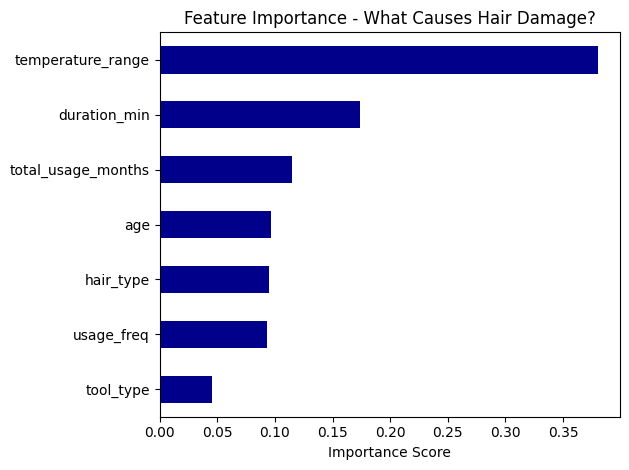

In [19]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh', color='darkblue')
plt.title('Feature Importance - What Causes Hair Damage?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [20]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Predicted:", y_pred)
print("Actual:", y_test.values)
print("Accuracy:", accuracy_score(y_test, y_pred)) 

Predicted: [5 2 4 ... 4 1 3]
Actual: [5 2 4 ... 4 1 3]
Accuracy: 0.8366666666666667


In [21]:
def risk_warning(score):
    if score == 0:
        return "No risk, your hair is healthy!"
    elif score == 1:
        return "Very mild risk, keep an eye on your hair!"
    elif score == 2:
        return "Mild risk, consider reducing heat usage!"
    elif score == 3:
        return "Moderate risk, reduce heat styling frequency!"
    elif score == 4:
        return "High risk, significantly reduce heat usage!"
    elif score == 5:
        return "Severe risk, stop heat styling immediately!"

# apply to predictions
for score in y_pred:
    print(f"Damage Score: {score} --> {risk_warning(score)}") 

Damage Score: 5 --> Severe risk, stop heat styling immediately!
Damage Score: 2 --> Mild risk, consider reducing heat usage!
Damage Score: 4 --> High risk, significantly reduce heat usage!
Damage Score: 5 --> Severe risk, stop heat styling immediately!
Damage Score: 3 --> Moderate risk, reduce heat styling frequency!
Damage Score: 2 --> Mild risk, consider reducing heat usage!
Damage Score: 2 --> Mild risk, consider reducing heat usage!
Damage Score: 4 --> High risk, significantly reduce heat usage!
Damage Score: 2 --> Mild risk, consider reducing heat usage!
Damage Score: 2 --> Mild risk, consider reducing heat usage!
Damage Score: 1 --> Very mild risk, keep an eye on your hair!
Damage Score: 3 --> Moderate risk, reduce heat styling frequency!
Damage Score: 4 --> High risk, significantly reduce heat usage!
Damage Score: 1 --> Very mild risk, keep an eye on your hair!
Damage Score: 2 --> Mild risk, consider reducing heat usage!
Damage Score: 4 --> High risk, significantly reduce heat u